## LUNG-001 - First inspection

First let's analyze some metadata for all the series. We are especially interested in the **Modality** property which indicates the type of series.

In [2]:
from pathlib import Path
import numpy as np
import pydicom

patient_dir = Path(
    "../data/raw/manifest-1603198545583/"
    "NSCLC-Radiomics/LUNG1-001/"
    "09-18-2008-StudyID-NA-69331"
)

for series_dir in patient_dir.iterdir():
    if not series_dir.is_dir():
        continue

    dcm_files = list(series_dir.glob("*dcm"))

    print("\nSeries:", series_dir.name)
    print("Number of files:", len(dcm_files))

    if dcm_files:
        ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)

        print("Modality:", getattr(ds, "Modality", None))
        print("SeriesDescription:", getattr(ds, "SeriesDescription", None))
        print("SOPClassUID:", getattr(ds, "SOPClassUID", None))
        print("SeriesInstanceUID:", getattr(ds, "SeriesInstanceUID", None))

Modality: SEG
SeriesDescription: Segmentation
SOPClassUID: 1.2.840.10008.5.1.4.1.1.66.4
SeriesInstanceUID: 1.2.276.0.7230010.3.1.3.2323910823.20524.1597260509.554


### Geometry of a CT-slice

In [3]:
ct_dir = Path(
    "../data/raw/manifest-1603198545583/"
    "NSCLC-Radiomics/LUNG1-001/"
    "09-18-2008-StudyID-NA-69331/"
    "0.000000-NA-82046"
)

ct_files = sorted(ct_dir.glob("*dcm"))

ds = pydicom.dcmread(ct_files[0])

print("Rows:", ds.Rows)
print("Columns:", ds.Columns)
print("PixelSpacing:", ds.PixelSpacing)
print("SliceThickness:", getattr(ds, "SliceThickness", None))
print("ImagePositionPatient:", getattr(ds, "ImagePositionPatient", None))
print("ImageOrientationPatient:", getattr(ds, "ImageOrientationPatient", None))
print("InstanceNumber:", getattr(ds, "InstanceNumber", None))

Rows: 512
Columns: 512
PixelSpacing: [0.9765625, 0.9765625]
SliceThickness: 3
ImagePositionPatient: [-249.51171875, -460.51171875, -282.5]
ImageOrientationPatient: [1, 0, 0, 0, 1, 0]
InstanceNumber: 1


Display values as Hounsfield Units (HU): HU = Pixel value * RescaleSlope + RescaleIntercept

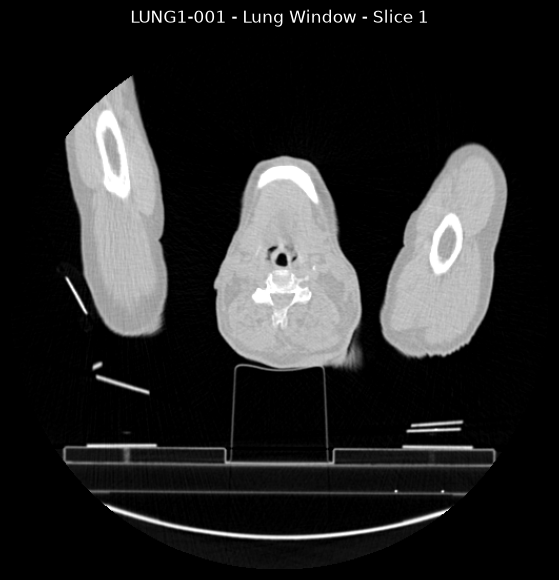

In [33]:
import matplotlib.pyplot as plt

pixels = ds.pixel_array.astype(np.float32)

slope = float(getattr(ds, "RescaleSlope", 1.0))
intercept = float(getattr(ds, "RescaleIntercept", 0.0))

hu = pixels * slope + intercept

print("HU range:", hu.min(), hu.max())

rows = int(ds.Rows)
cols = int(ds.Columns)

row_spacing, col_spacing = map(float, ds.PixelSpacing)

width_mm = cols * col_spacing
height_mm = rows * row_spacing

plt.figure(figsize=(7, 7))
plt.imshow(hu,
           cmap="gray",
           vmin=-1000,
           vmax=400,
           extent=[0, width_mm, height_mm, 0],)
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"LUNG1-001 - Lung Window - Slice {ds.InstanceNumber}")
plt.axis("off")
plt.show()

### Creating a volume out of the CT-slices

In [5]:
slices = [
    pydicom.dcmread(path)
    for path in ct_files
]

slices.sort(
    key=lambda ds: float(ds.ImagePositionPatient[2])
)

volume = []

for ds in slices:
    pixels = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))

    volume.append(pixels * slope + intercept)

volume = np.stack(volume)

print(volume.shape)

(134, 512, 512)


### Show a middle slice

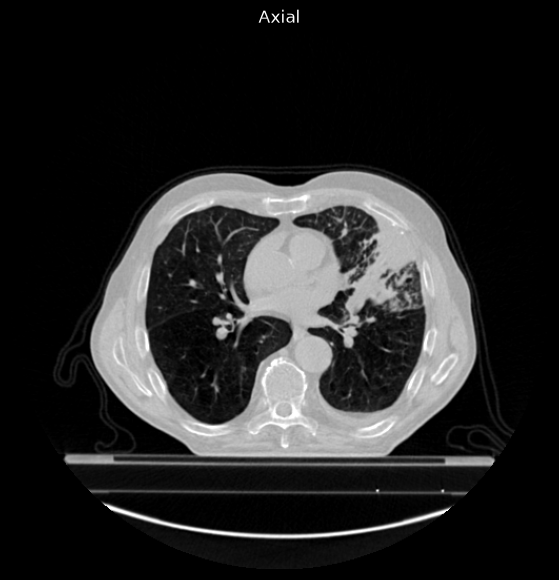

In [6]:
axial = volume[volume.shape[0] // 2, :, :]
coronal = volume[:, volume.shape[1] // 2, :]
sagittal = volume[:, :, volume.shape[2] // 2]

plt.figure(figsize=(7, 7))
plt.imshow(axial, cmap="gray", vmin=-1000, vmax=400)
plt.title("Axial")
plt.axis("off")
plt.show()

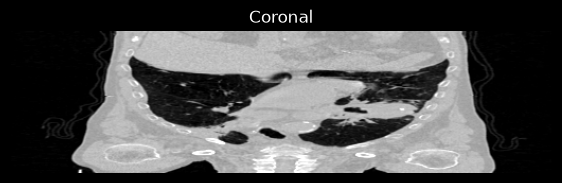

In [7]:
plt.figure(figsize=(7, 7))
plt.imshow(coronal, cmap="gray", vmin=-1000, vmax=400)
plt.title("Coronal")
plt.axis("off")
plt.show()

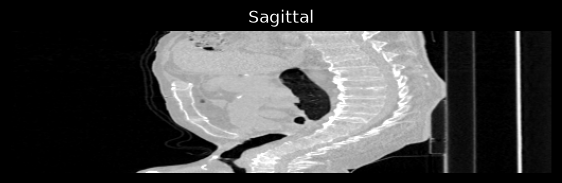

In [8]:
plt.figure(figsize=(7, 7))
plt.imshow(sagittal, cmap="gray", vmin=-1000, vmax=400)
plt.title("Sagittal")
plt.axis("off")
plt.show()

### Overlaying tumor mask onto a CT-slice by using the SEG-frames

In [9]:
seg_path = Path(
    "../data/raw/manifest-1603198545583/"
    "NSCLC-Radiomics/LUNG1-001/"
    "09-18-2008-StudyID-NA-69331/"
    "300.000000-Segmentation-9.554/"
)

seg_file = next(seg_path.glob("*.dcm"))
seg_ds = pydicom.dcmread(seg_file)

print("Modality:", seg_ds.Modality)
print("Rows:", seg_ds.Rows)
print("Columns:", seg_ds.Columns)
print("NumberOfFrames:", getattr(seg_ds, "NumberOfFrames", None))
print("Segments:", len(getattr(seg_ds, "SegmentSequence", [])))

Modality: SEG
Rows: 512
Columns: 512
NumberOfFrames: 536
Segments: 4


In [10]:
for segment in seg_ds.SegmentSequence:
    print("SegmentNumber:", segment.SegmentNumber)
    print("SegmentLabel:", getattr(segment, "SegmentLabel", None))
    print("SegmentDescription:", getattr(segment, "SegmentDescription", None))
    print("---")

SegmentNumber: 1
SegmentLabel: Neoplasm, Primary
SegmentDescription: GTV-1
---
SegmentNumber: 2
SegmentLabel: Lung
SegmentDescription: Lung-Left
---
SegmentNumber: 3
SegmentLabel: Lung
SegmentDescription: Lung-Right
---
SegmentNumber: 4
SegmentLabel: Spinal cord
SegmentDescription: Spinal-Cord
---


In [11]:
seg_array = seg_ds.pixel_array

print(seg_array.shape)
print(seg_array.dtype)
print(seg_array.min(), seg_array.max())

(536, 512, 512)
uint8
0 1


#### Showing a SEG-frame

In [12]:
nonempty_frames = [
    i for i in range(seg_array.shape[0])
    if np.any(seg_array[i] > 0)
]

print("Non-empty frames:", nonempty_frames)

Non-empty frames: [65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 429, 430, 431, 432, 433, 43

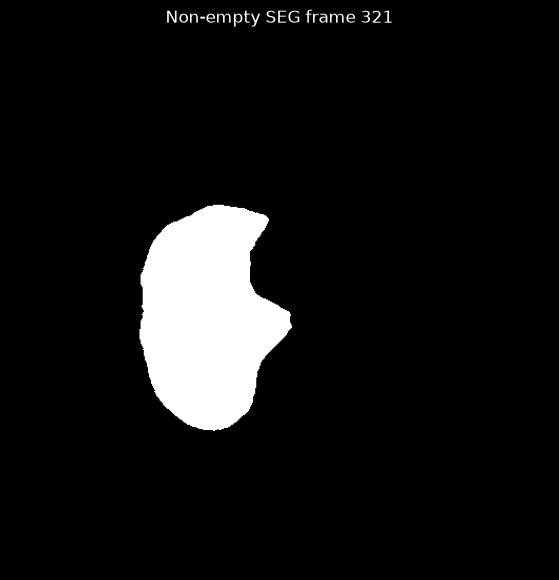

In [13]:
frame_idx = nonempty_frames[len(nonempty_frames) // 2]

plt.figure(figsize=(7, 7))
plt.imshow(seg_array[frame_idx], cmap="gray")
plt.title(f"Non-empty SEG frame {frame_idx}")
plt.axis("off")
plt.show()

#### Which SEG-frame corresponds to which CT-slice?

Spacial Position for a frame

In [14]:
fg = seg_ds.PerFrameFunctionalGroupsSequence[frame_idx]

plane_position = fg.PlanePositionSequence[0]
print("SEG ImagePositionPatient:", plane_position.ImagePositionPatient)

SEG ImagePositionPatient: [-2.495117e+002, -4.605117e+002, -5.225000e+002]


Compare this position with the CT-slices

In [15]:
for i, ct_ds in enumerate(slices):
    print(i, ct_ds.ImagePositionPatient)

0 [-249.51171875, -460.51171875, -681.5]
1 [-249.51171875, -460.51171875, -678.5]
2 [-249.51171875, -460.51171875, -675.5]
3 [-249.51171875, -460.51171875, -672.5]
4 [-249.51171875, -460.51171875, -669.5]
5 [-249.51171875, -460.51171875, -666.5]
6 [-249.51171875, -460.51171875, -663.5]
7 [-249.51171875, -460.51171875, -660.5]
8 [-249.51171875, -460.51171875, -657.5]
9 [-249.51171875, -460.51171875, -654.5]
10 [-249.51171875, -460.51171875, -651.5]
11 [-249.51171875, -460.51171875, -648.5]
12 [-249.51171875, -460.51171875, -645.5]
13 [-249.51171875, -460.51171875, -642.5]
14 [-249.51171875, -460.51171875, -639.5]
15 [-249.51171875, -460.51171875, -636.5]
16 [-249.51171875, -460.51171875, -633.5]
17 [-249.51171875, -460.51171875, -630.5]
18 [-249.51171875, -460.51171875, -627.5]
19 [-249.51171875, -460.51171875, -624.5]
20 [-249.51171875, -460.51171875, -621.5]
21 [-249.51171875, -460.51171875, -618.5]
22 [-249.51171875, -460.51171875, -615.5]
23 [-249.51171875, -460.51171875, -612.5]
24

#### Match CT-index with SEG-position

In [16]:
seg_position = np.asarray(
    seg_ds
    .PerFrameFunctionalGroupsSequence[frame_idx]
    .PlanePositionSequence[0]
    .ImagePositionPatient,
    dtype=float
)

ct_positions = np.asarray([
    ds.ImagePositionPatient
    for ds in slices
], dtype=float)

distances = np.linalg.norm(ct_positions - seg_position, axis=1)

ct_idx = np.argmin(distances)

tolerance_mm = 1e-3

if distances[ct_idx] > tolerance_mm:
    raise ValueError(
        f"No matching CT slice found for SEG frame {frame_idx}. "
        f"Closest distance: {distances[ct_idx]:.3f} mm"
    )

print("SEG position:", seg_position)
print("Matched CT position:", ct_positions[ct_idx])
print("Distance:", distances[ct_idx], "mm")
print("CT index:", ct_idx)

SEG position: [-249.5117 -460.5117 -522.5   ]
Matched CT position: [-249.51171875 -460.51171875 -522.5       ]
Distance: 2.6516504287839346e-05 mm
CT index: 53


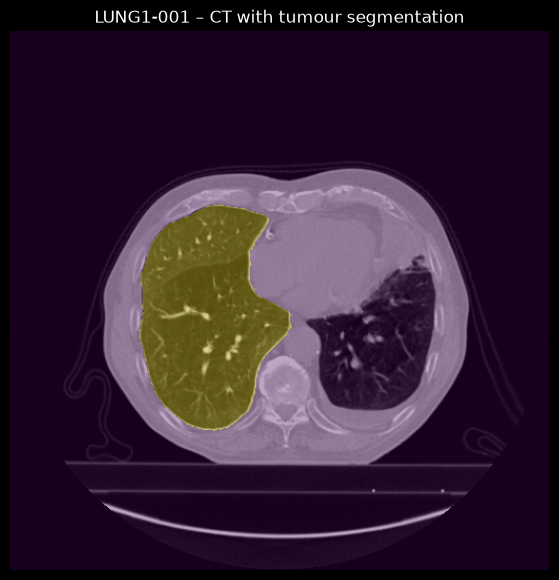

In [17]:
ct_slice = volume[ct_idx]
mask = seg_array[frame_idx] > 0

plt.figure(figsize=(7, 7))
plt.imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
plt.imshow(mask, alpha=0.35)
plt.title("LUNG1-001 – CT with tumour segmentation")
plt.axis("off")
plt.show()

### For each SEG-frame, find to which segment it belongs

In [18]:
for frame_idx, fg in enumerate(seg_ds.PerFrameFunctionalGroupsSequence[:10]):
    segment_number = (
        fg
        .SegmentIdentificationSequence[0]
        .ReferencedSegmentNumber
    )

    print(frame_idx, segment_number)

0 1
1 1
2 1
3 1
4 1
5 1
6 1
7 1
8 1
9 1


Group frames

In [19]:
from collections import defaultdict

frames_by_segment = defaultdict(list)

for frame_idx, fg in enumerate(seg_ds.PerFrameFunctionalGroupsSequence):
    segment_number = int(
        fg
        .SegmentIdentificationSequence[0]
        .ReferencedSegmentNumber
    )

    frames_by_segment[segment_number].append(frame_idx)

for segment_number, frame_indices in frames_by_segment.items():
    print(
        f"Segment {segment_number}: "
        f"{len(frame_indices)} frames"
    )

Segment 1: 134 frames
Segment 2: 134 frames
Segment 3: 134 frames
Segment 4: 134 frames


In [20]:
segment_info = {
    int(segment.SegmentNumber): {
        "label": getattr(segment, "SegmentLabel", None),
        "description": getattr(segment, "SegmentDescription", None),
    }
    for segment in seg_ds.SegmentSequence
}

for segment_number, frame_indices in frames_by_segment.items():
    info = segment_info[segment_number]

    print(
        f"Segment {segment_number} | "
        f"{info['label']} | "
        f"{info['description']} | "
        f"{len(frame_indices)} frames"
    )

Segment 1 | Neoplasm, Primary | GTV-1 | 134 frames
Segment 2 | Lung | Lung-Left | 134 frames
Segment 3 | Lung | Lung-Right | 134 frames
Segment 4 | Spinal cord | Spinal-Cord | 134 frames


Which frames of the segments are non-empty?

In [22]:
for segment_number, frame_indices in frames_by_segment.items():
    nonempty = [
        frame_idx
        for frame_idx in frame_indices
        if np.any(seg_array[frame_idx] > 0)
    ]

    info = segment_info[segment_number]

    print(
        f"Segment {segment_number} | "
        f"{info['description']} | "
        f"{len(nonempty)} non-empty of {len(frame_indices)} frames"
    )

Segment 1 | GTV-1 | 21 non-empty of 134 frames
Segment 2 | Lung-Left | 88 non-empty of 134 frames
Segment 3 | Lung-Right | 86 non-empty of 134 frames
Segment 4 | Spinal-Cord | 84 non-empty of 134 frames


In [21]:
gtv_frames = frames_by_segment[1]

frame_idx = gtv_frames[len(gtv_frames) // 2]
mask = seg_array[frame_idx] > 0

Where are those frames in the 3 dimensional space?

In [23]:
# CT positions
ct_positions = np.array(
    [
        np.array(ds.ImagePositionPatient, dtype=float)
        for ds in slices
    ]
)

def get_seg_position(seg_ds, frame_idx):
    fg = seg_ds.PerFrameFunctionalGroupsSequence[frame_idx]
    return np.array(
        fg.PlanePositionSequence[0].ImagePositionPatient,
        dtype=float
    )

def match_ct_slice(seg_position, ct_positions):
    distances = np.linalg.norm(
        ct_positions - seg_position,
        axis=1
    )
    ct_idx = int(np.argmin(distances))
    return ct_idx, distances[ct_idx]

In [26]:
matches = []

for frame_idx, fg in enumerate(
    seg_ds.PerFrameFunctionalGroupsSequence
):
    segment_number = int(
        fg.SegmentIdentificationSequence[0]
        .ReferencedSegmentNumber
    )

    seg_position = np.array(
        fg.PlanePositionSequence[0]
        .ImagePositionPatient,
        dtype=float
    )

    ct_idx, distance = match_ct_slice(
        seg_position,
        ct_positions
    )

    matches.append({
        "frame_idx": frame_idx,
        "segment_number": segment_number,
        "ct_idx": ct_idx,
        "distance_mm": distance
    })

max_distance = max(
    match["distance_mm"]
    for match in matches
)

print("Maximum matching distance:", max_distance)

Maximum matching distance: 2.6516504287839346e-05


In [27]:
from collections import defaultdict

ct_indices_by_segment = defaultdict(list)

for match in matches:
    ct_indices_by_segment[
        match["segment_number"]
    ].append(match["ct_idx"])

for segment_number, ct_indices in ct_indices_by_segment.items():
    print(
        segment_number,
        len(ct_indices),
        len(set(ct_indices)),
        min(ct_indices),
        max(ct_indices)
    )

1 134 134 0 133
2 134 134 0 133
3 134 134 0 133
4 134 134 0 133
